<a href="https://colab.research.google.com/github/vikram071/student-database/blob/main/run_experiments_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP9417 xRFM Group Project - Experiments

This notebook trains xRFM and XGBoost on all 5 datasets, evaluates performance, and saves results to `results/results.csv`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup and Imports

In [ ]:
!pip3 install xgboost

In [ ]:
!pip3 install xrfm

In [ ]:
import sys
import time
import threading
import warnings
from pathlib import Path
import xgboost as xgb

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    r2_score,
)
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

## 2. Configuration

In [ ]:
from pathlib import Path


In [ ]:
# Determine base directory (adjust if needed)
from pathlib import Path

# Define base directory (adjust if needed, e.g., to current working directory)
# BASE_DIR = Path.cwd()
BASE_DIR = Path('/content/drive/MyDrive/project')

# Define and create the results directory
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True) # parents=True creates intermediate directories

print(f"Results directory prepared at: {RESULTS_DIR}")


RANDOM_SEED = 42

# Dataset metadata
DATASETS = {
    "superconductivity": {"task": "regression"},
    "seoul_bike":        {"task": "regression"},
    "online_shoppers":   {"task": "classification"},
    "cdc_diabetes":      {"task": "classification"},
    "bankruptcy":        {"task": "classification"},
}

print(f"Base directory: {BASE_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")

Results directory prepared at: /content/drive/MyDrive/project/results
Base directory: /content/drive/MyDrive/project
Results will be saved to: /content/drive/MyDrive/project/results


## 3. Helper Classes and Functions

In [ ]:
class _Spinner:
    """Shows elapsed time while a blocking call runs."""
    def __init__(self, label):
        self._label = label
        self._stop = threading.Event()
        self._t = threading.Thread(target=self._run, daemon=True)

    def _run(self):
        chars = "|/-\\"
        i = 0
        start = time.time()
        while not self._stop.is_set():
            elapsed = time.time() - start
            print(f"\r  {self._label} {chars[i % 4]}  {elapsed:.1f}s elapsed", end="", flush=True)
            i += 1
            time.sleep(0.2)

    def __enter__(self):
        self._t.start()
        return self

    def __exit__(self, *_):
        self._stop.set()
        self._t.join()
        print("\r" + " " * 60 + "\r", end="", flush=True)

In [ ]:
def load_splits(name):
    """Load preprocessed train/val/test splits for a dataset."""
    path = BASE_DIR / "preprocessed_data" / f"{name}.npz"
    d = np.load(path)
    return (
        d["X_train"], d["X_val"], d["X_test"],
        d["y_train"], d["y_val"], d["y_test"],
    )

In [ ]:
def regression_metrics(y_true, y_pred):
    """Calculate regression metrics: RMSE, MAE, R2."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4), "R2": round(r2, 4)}


def classification_metrics(y_true, y_pred, y_proba=None):
    """Calculate classification metrics: Accuracy, AUC-ROC."""
    acc = float(accuracy_score(y_true, y_pred))
    metrics = {"Accuracy": round(acc, 4)}
    if y_proba is not None:
        try:
            auc = float(roc_auc_score(y_true, y_proba))
            metrics["AUC-ROC"] = round(auc, 4)
        except Exception:
            metrics["AUC-ROC"] = None
    return metrics

## 4. xRFM Model Runner

In [ ]:
def run_xrfm(name, task, X_train, X_val, X_test, y_train, y_val, y_test):
    """Train and evaluate xRFM model."""
    print(f"  [xRFM] training on {name} ...")
    from xrfm.xrfm import xRFM

    is_clf = task == "classification"
    classes = np.unique(y_train) if is_clf else None

    tuning = "auc" if is_clf else "mse"
    rfm_params = {
        "model": {
            "kernel": "l2",
            "iters": 5,
            "bandwidth": 10.0,
            "exponent": 1.0,
        },
        "fit": {
            "iters": 5,
            "reg": 1e-3,   # must be explicit — library has no default
        },
    }

    model = xRFM(
        rfm_params=rfm_params,
        max_leaf_size=60_000,
        device="cuda",
        classification_mode="zero_one" if is_clf else None,
        tuning_metric=tuning,
        random_state=RANDOM_SEED,
    )

    t0 = time.time()
    with _Spinner(f"[xRFM] fitting on {name}"):
        model.fit(X_train, y_train, X_val, y_val)
    train_time = time.time() - t0
    print(f"  [xRFM] fit done in {train_time:.1f}s", flush=True)

    t1 = time.time()
    with _Spinner(f"[xRFM] predicting on {name}"):
        y_pred = model.predict(X_test)
    pred_time = time.time() - t1

    y_proba = None
    if is_clf:
        try:
            proba = model.predict_proba(X_test)
            if proba.ndim == 2:
                y_proba = proba[:, 1]
            else:
                y_proba = proba
        except Exception:
            pass

    if is_clf:
        metrics = classification_metrics(y_test, y_pred, y_proba)
    else:
        metrics = regression_metrics(y_test, y_pred)

    metrics["Train_Time_s"] = round(train_time, 2)
    metrics["Pred_Time_s"]  = round(pred_time, 4)
    return metrics

## 5. XGBoost Model Runner

In [ ]:
class _XGBTqdmCallback:
    """Minimal XGBoost callback that drives a tqdm bar."""
    def __init__(self, total, desc):
        self._bar = tqdm(total=total, desc=desc, unit="tree", ncols=80, leave=False)

    def after_iteration(self, model, epoch, evals_log):
        self._bar.update(1)
        return False

    def after_training(self, model):
        self._bar.close()
        return model

In [ ]:
def run_xgboost(name, task, X_train, X_val, X_test, y_train, y_val, y_test):
    """Train and evaluate XGBoost model."""
    print(f"  [XGBoost] training on {name} ...", flush=True)
    import xgboost as xgb

    is_clf = task == "classification"
    N_TREES = 300
    EARLY_STOP = 20

    common = dict(
        n_estimators=N_TREES,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=EARLY_STOP,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    )
    if is_clf:
        model = xgb.XGBClassifier(eval_metric="logloss", **common)
    else:
        model = xgb.XGBRegressor(**common)

    t0 = time.time()
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.time() - t0
    print(f"  [XGBoost] fit done in {train_time:.1f}s  "
          f"(best iter: {model.best_iteration})", flush=True)

    t1 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t1

    y_proba = None
    if is_clf:
        y_pred_int = y_pred.astype(int)
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except Exception:
            pass
        metrics = classification_metrics(y_test, y_pred_int, y_proba)
    else:
        metrics = regression_metrics(y_test, y_pred)

    metrics["Train_Time_s"] = round(train_time, 2)
    metrics["Pred_Time_s"]  = round(pred_time, 4)
    return metrics

In [ ]:
# ── Section 5b. Random Forest Baseline ──────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

def run_random_forest(name, task, X_train, X_val, X_test, y_train, y_val, y_test):
    """Train and evaluate a Random Forest baseline model."""
    print(f"  [RandomForest] training on {name} ...", flush=True)

    is_clf = task == "classification"

    common = dict(
        n_estimators=300,
        max_depth=None,          # grow full trees (RF handles overfitting via bagging)
        min_samples_leaf=1,
        max_features="sqrt",     # standard heuristic for both clf & reg
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )

    model = RandomForestClassifier(**common) if is_clf else RandomForestRegressor(**common)

    t0 = time.time()
    model.fit(X_train, y_train)          # RF has no early stopping; val set not used in fit
    train_time = time.time() - t0
    print(f"  [RandomForest] fit done in {train_time:.1f}s", flush=True)

    t1 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t1

    y_proba = None
    if is_clf:
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except Exception:
            pass
        metrics = classification_metrics(y_test, y_pred.astype(int), y_proba)
    else:
        metrics = regression_metrics(y_test, y_pred)

    metrics["Train_Time_s"] = round(train_time, 2)
    metrics["Pred_Time_s"]  = round(pred_time, 4)
    return metrics

## 6. Run Experiments

In [ ]:
records = []
ds_items = list(DATASETS.items())

outer = tqdm(ds_items, desc="Datasets", unit="ds", ncols=80)
for ds_name, ds_info in outer:
    task = ds_info["task"]
    outer.set_postfix(dataset=ds_name)
    print(f"\n{'='*60}", flush=True)
    print(f"Dataset: {ds_name}  |  Task: {task}", flush=True)
    print(f"{'='*60}", flush=True)

    X_train, X_val, X_test, y_train, y_val, y_test = load_splits(ds_name)
    print(f"  Splits: train={X_train.shape[0]}, val={X_val.shape[0]}, "
          f"test={X_test.shape[0]}, d={X_train.shape[1]}", flush=True)

    # ── xRFM ──
    try:
        xrfm_metrics = run_xrfm(
            ds_name, task,
            X_train, X_val, X_test, y_train, y_val, y_test,
        )
        print(f"  xRFM   -> {xrfm_metrics}", flush=True)
        records.append({"Dataset": ds_name, "Task": task,
                         "Model": "xRFM", **xrfm_metrics})
    except Exception as e:
        print(f"  xRFM FAILED: {e}", flush=True)

    # ── XGBoost ──
    try:
        xgb_metrics = run_xgboost(
            ds_name, task,
            X_train, X_val, X_test, y_train, y_val, y_test,
        )
        print(f"  XGBoost -> {xgb_metrics}", flush=True)
        records.append({"Dataset": ds_name, "Task": task,
                         "Model": "XGBoost", **xgb_metrics})
    except Exception as e:
        print(f"  XGBoost FAILED: {e}", flush=True)
    # ── Random Forest ──
    try:
        rf_metrics = run_random_forest(
            ds_name, task,
            X_train, X_val, X_test, y_train, y_val, y_test,
        )
        print(f"  RandomForest -> {rf_metrics}", flush=True)
        records.append({"Dataset": ds_name, "Task": task,
                         "Model": "RandomForest", **rf_metrics})
    except Exception as e:
        print(f"  RandomForest FAILED: {e}", flush=True)

Datasets:   0%|                                           | 0/5 [00:00<?, ?ds/s]


Dataset: superconductivity  |  Task: regression
  Splits: train=14883, val=3190, test=3190, d=81
  [xRFM] training on superconductivity ...
  [xRFM] fitting on superconductivity |  0.0s elapsedFitting xRFM with 1 trees and 0 iterations per tree



Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

  [xRFM] fitting on superconductivity -  0.4s elapsed

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

...


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

  [xRFM] fitting on bankruptcy /  0.2s elapsed

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Tree has no split, stopping training
  [xRFM] fit done in 0.4s
  [xRFM] predicting on bankruptcy |  0.0s elapsed

  xRFM   -> {'Accuracy': 0.9697, 'AUC-ROC': 0.8222, 'Train_Time_s': 0.4, 'Pred_Time_s': 0.2019}
  [XGBoost] training on bankruptcy ...
  [XGBoost] fit done in 0.2s  (best iter: 39)
  XGBoost -> {'Accuracy': 0.9677, 'AUC-ROC': 0.9466, 'Train_Time_s': 0.21, 'Pred_Time_s': 0.0014}
  [RandomForest] training on bankruptcy ...
  [RandomForest] fit done in 1.4s
  RandomForest -> {'Accuracy': 0.9707, 'AUC-ROC': 0.9368, 'Train_Time_s': 1.35, 'Pred_Time_s': 0.0863}


## 7. Save and Display Results

In [ ]:
df = pd.DataFrame(records)
out = RESULTS_DIR / "results.csv"
df.to_csv(out, index=False)
print(f"\nResults saved to {out}")
df


Results saved to /content/drive/MyDrive/project/results/results.csv


,Dataset,Task,Model,RMSE,MAE,R2,Train_Time_s,Pred_Time_s,Accuracy,AUC-ROC
0,superconductivity,regression,xRFM,9.2466,5.0304,0.9258,0.60,0.2016,NaN,NaN
1,superconductivity,regression,XGBoost,9.4099,5.6194,0.9232,12.45,0.0100,NaN,NaN
2,superconductivity,regression,RandomForest,9.1468,5.2445,0.9274,5.79,0.1190,NaN,NaN
3,seoul_bike,regression,xRFM,252.6643,147.8360,0.8454,0.40,0.2020,NaN,NaN
4,seoul_bike,regression,XGBoost,225.5556,138.8250,0.8768,0.21,0.0019,NaN,NaN
5,seoul_bike,regression,RandomForest,241.4097,147.7699,0.8589,0.64,0.0986,NaN,NaN
6,online_shoppers,classification,xRFM,NaN,NaN,NaN,0.60,0.2018,0.8822,0.8858
7,online_shoppers,classification,XGBoost,NaN,NaN,NaN,0.12,0.0016,0.9054,0.9339
8,online_shoppers,classification,RandomForest,NaN,NaN,NaN,0.80,0.0884,0.9005,0.9216
9,cdc_diabetes,classification,xRFM,NaN,NaN,NaN,105.61,0.4029,0.8629,0.8087


Dataset: cdc_diabetes  |  full train n = 177576
Subsampling at sizes: [8878, 17757, 35515, 71030, 106545, 142060, 177576]

── n = 8878 ──────────────────────────────
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Tree has no split, stopping training
  xRFM        AUC=0.7671  t=0.7s
  XGBoost     AUC=0.8192  t=0.1s


  RandomForest AUC=0.7993  t=0.7s

── n = 17757 ──────────────────────────────
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:02<?, ?it/s]

...

Selected split_temperature=3.4238439377355454 based on validation auc=0.809237
  xRFM        AUC=0.8047  t=65.6s
  XGBoost     AUC=0.8270  t=3.0s
  RandomForest AUC=0.7988  t=5.6s

── n = 177576 ──────────────────────────────
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([46852, 21]) y_train torch.Size([46852, 1]) X_val torch.Size([2466, 21]) y_val torch.Size([2466, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([46837, 21]) y_train torch.Size([46837, 1]) X_val torch.Size([2466, 21]) y_val torch.Size([2466, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([46836, 21]) y_train torch.Size([46836, 1]) X_val torch.Size([2466, 21]) y_val torch.Size([2466, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.


Tuning split temperature: 100%|██████████| 21/21 [00:03<00:00,  5.31it/s]


Selected split_temperature=4.500000000000001 based on validation auc=0.814158
  xRFM        AUC=0.8083  t=106.4s
  XGBoost     AUC=0.8278  t=0.9s
  RandomForest AUC=0.7987  t=8.7s


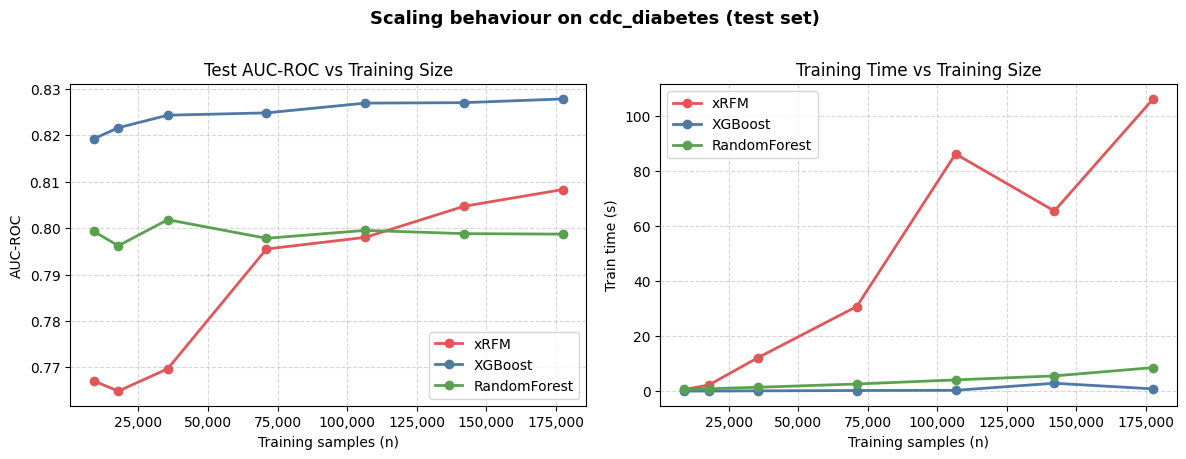

Saved to /content/drive/MyDrive/project/results/scaling_plot.png
       model      n    auc  train_time
        xRFM   8878 0.7671        0.70
     XGBoost   8878 0.8192        0.12
RandomForest   8878 0.7993        0.74
        xRFM  17757 0.7649        2.29
     XGBoost  17757 0.8216        0.15
RandomForest  17757 0.7962        0.97
        xRFM  35515 0.7697       12.29
     XGBoost  35515 0.8243        0.22
RandomForest  35515 0.8018        1.52
        xRFM  71030 0.7955       30.89
     XGBoost  71030 0.8248        0.34
RandomForest  71030 0.7978        2.71
        xRFM 106545 0.7980       86.38
     XGBoost 106545 0.8269        0.41
RandomForest 106545 0.7995        4.20
        xRFM 142060 0.8047       65.63
     XGBoost 142060 0.8270        2.98
RandomForest 142060 0.7988        5.65
        xRFM 177576 0.8083      106.38
     XGBoost 177576 0.8278        0.93
RandomForest 177576 0.7987        8.67


In [ ]:
# ── Section 8. Scaling Plot ──────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import time

SCALING_DATASET = "cdc_diabetes"   # ← change if a larger dataset exists
SCALING_TASK    = "classification"
RANDOM_SEED     = 42

# Subsampling fractions → absolute sizes will be printed so you can verify
FRACTIONS = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

X_train, X_val, X_test, y_train, y_val, y_test = load_splits(SCALING_DATASET)
n_full = X_train.shape[0]
sizes  = [max(100, int(f * n_full)) for f in FRACTIONS]
sizes  = sorted(set(sizes))   # deduplicate if fractions collapse
print(f"Dataset: {SCALING_DATASET}  |  full train n = {n_full}")
print(f"Subsampling at sizes: {sizes}")

rng = np.random.default_rng(RANDOM_SEED)

scaling_records = []   # [{model, n, auc, train_time}]

for n in sizes:
    idx = rng.choice(n_full, size=n, replace=False)
    Xs, ys = X_train[idx], y_train[idx]
    print(f"\n── n = {n} ──────────────────────────────")

    # ── xRFM ──
    try:
        t0 = time.time()
        from xrfm.xrfm import xRFM
        rfm_params = {
            "model": {"kernel": "l2", "iters": 5, "bandwidth": 10.0,
                      "exponent": 1.0},
            "fit":   {"iters": 5, "reg": 1e-3},
        }
        m = xRFM(rfm_params=rfm_params, max_leaf_size=60_000, device="cuda",
                 classification_mode="zero_one", tuning_metric="auc",
                 random_state=RANDOM_SEED)
        m.fit(Xs, ys, X_val, y_val)
        train_time = time.time() - t0
        proba = m.predict_proba(X_test)
        y_proba = proba[:, 1] if proba.ndim == 2 else proba
        auc = roc_auc_score(y_test, y_proba)
        scaling_records.append({"model": "xRFM", "n": n,
                                 "auc": round(auc, 4),
                                 "train_time": round(train_time, 2)})
        print(f"  xRFM        AUC={auc:.4f}  t={train_time:.1f}s")
    except Exception as e:
        print(f"  xRFM FAILED: {e}")
    # ── XGBoost ──
    try:
        t0 = time.time()
        m = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               early_stopping_rounds=20, eval_metric="logloss",
                               random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
        m.fit(Xs, ys, eval_set=[(X_val, y_val)], verbose=False)
        train_time = time.time() - t0
        auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
        scaling_records.append({"model": "XGBoost", "n": n,
                                 "auc": round(auc, 4),
                                 "train_time": round(train_time, 2)})
        print(f"  XGBoost     AUC={auc:.4f}  t={train_time:.1f}s")
    except Exception as e:
        print(f"  XGBoost FAILED: {e}")

    # ── Random Forest ──
    try:
        t0 = time.time()
        m = RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                   n_jobs=-1, random_state=RANDOM_SEED)
        m.fit(Xs, ys)
        train_time = time.time() - t0
        auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
        scaling_records.append({"model": "RandomForest", "n": n,
                                 "auc": round(auc, 4),
                                 "train_time": round(train_time, 2)})
        print(f"  RandomForest AUC={auc:.4f}  t={train_time:.1f}s")
    except Exception as e:
        print(f"  RandomForest FAILED: {e}")

# ── Plot ─────────────────────────────────────────────────────────────────────

scale_df = pd.DataFrame(scaling_records)

COLORS = {"xRFM": "#e15759", "XGBoost": "#4e79a7", "RandomForest": "#59a14f"}
MODELS = ["xRFM", "XGBoost", "RandomForest"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"Scaling behaviour on {SCALING_DATASET} (test set)",
             fontsize=13, fontweight="bold", y=1.01)

for model in MODELS:
    sub = scale_df[scale_df["model"] == model].sort_values("n")
    if sub.empty:
        continue
    c = COLORS[model]
    ax1.plot(sub["n"], sub["auc"],      marker="o", color=c, label=model, linewidth=2)
    ax2.plot(sub["n"], sub["train_time"], marker="o", color=c, label=model, linewidth=2)

ax1.set_title("Test AUC-ROC vs Training Size")
ax1.set_xlabel("Training samples (n)")
ax1.set_ylabel("AUC-ROC")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2.set_title("Training Time vs Training Size")
ax2.set_xlabel("Training samples (n)")
ax2.set_ylabel("Train time (s)")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scaling_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS_DIR / 'scaling_plot.png'}")

# Save raw numbers too
scale_df.to_csv(RESULTS_DIR / "scaling_results.csv", index=False)
print(scale_df.to_string(index=False))